PROJECT

IMPORT + PARAMETERS

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

In [2]:
import env as env_module
import agents as agent_module
import env_penalty as env_penalty_module
import agents_penalty as agents_penalty_module

In [4]:
n_episodes = 100000
n_steps=50
window = 200

PLOTS

In [5]:
def plot_convergence(sw_history, pol_history, window=window):
    # Apply moving average smoothing
    sw_smoothed = np.convolve(sw_history, np.ones(window)/window, mode='valid')
    pol_smoothed = np.convolve(pol_history, np.ones(window)/window, mode='valid')

    plt.figure(figsize=(14, 5))

    # Plot Social Welfare
    plt.subplot(1, 2, 1)
    plt.plot(sw_history, alpha=0.3, color='blue', label='Raw')
    plt.plot(sw_smoothed, color='darkblue', linewidth=2, label=f'Mean ({window})')
    plt.title("Social Welfare Evolution ($SW$)")
    plt.xlabel("Episodes")
    plt.ylabel("Score SW")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot Pollution
    plt.subplot(1, 2, 2)
    plt.plot(pol_history, alpha=0.3, color='red', label='Raw')
    plt.plot(pol_smoothed, color='darkred', linewidth=2, label=f'Mean ({window})')
    plt.title("Final Pollution Stock")
    plt.xlabel("Episodes")
    plt.ylabel("Pollution level")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [6]:
def plot_gov_decisions(gov_agent):
    states = sorted(gov_agent.q_table.keys())
    best_actions = []

    for s in states:
        idx = np.argmax(gov_agent.q_table[s])
        a_type, a_val = gov_agent.actions[idx]
        best_actions.append((s * 5, a_type, a_val)) 

    pollutions = [x[0] for x in best_actions]
    types = ["Taxe" if x[1] == 0 else "Quota" for x in best_actions]
    values = [x[2] for x in best_actions]

    plt.figure(figsize=(12, 5))

    
    colors = ['blue' if t == "Tax" else 'orange' for t in types]
    plt.scatter(pollutions, values, c=colors, s=100, edgecolors='black', alpha=0.7)
    plt.title("Optimal policy chosen according to pollution level")
    plt.xlabel("Pollution Level")
    plt.ylabel("Policy Value (Tax or Quota)")
    plt.grid(True, linestyle='--', alpha=0.6)


    legend_elements = [Line2D([0], [0], marker='o', color='w', label='Tax', markerfacecolor='blue', markersize=10),
                       Line2D([0], [0], marker='o', color='w', label='Quota', markerfacecolor='orange', markersize=10)]
    plt.legend(handles=legend_elements)
    plt.show()

In [7]:
def plot_policy_responses(firms_list):
    tax_values = [0, 1, 2, 3, 4, 5]
    quota_values = [2, 4, 6, 8, 10]

    plt.figure(figsize=(15, 6))
    styles = ['-', '--', ':', '-.', (0, (3, 5, 1, 5))]

    plt.subplot(1, 2, 1)
    for i, f in enumerate(firms_list):
        responses = []
        for v in tax_values:
            state_key = (0, float(v))
            if state_key in f.q_table:
                best_action_idx = np.argmax(f.q_table[state_key])
                responses.append(f.actions[best_action_idx])
            else:
                responses.append(None)

        plt.plot(tax_values, responses, marker='o', label=f"Firm {i+1} (a_i={1+i})")

    plt.title("Learned Production vs. Tax Level")
    plt.xlabel("Tax Value")
    plt.ylabel("Quantity Produced $q$")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    for i, f in enumerate(firms_list):
        responses = []
        for v in quota_values:
            state_key = (1, float(v))
            if state_key in f.q_table:
                best_action_idx = np.argmax(f.q_table[state_key])
                responses.append(f.actions[best_action_idx])
            else:
                responses.append(None)

        plt.plot(quota_values, responses, marker='s', label=f"Firm {i+1}")
    plt.title("Learned Production vs. Quota Level")
    plt.xlabel("Quota Value (Legislative)")
    plt.ylabel("Quantity Produced $q$")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_comparison_SW(history_q, history_sarsa, window=window):
    q_smoothed = np.convolve(history_q, np.ones(window)/window, mode='valid')
    sarsa_smoothed = np.convolve(history_sarsa, np.ones(window)/window, mode='valid')
    
    plt.figure(figsize=(12, 6))
    plt.plot(q_smoothed, label="Q-Learning", color='blue', alpha=0.8)
    plt.plot(sarsa_smoothed, label="Expected SARSA", color='green', alpha=0.8)

    plt.title("Comparison : Q-Learning vs Expected SARSA")
    plt.xlabel("Episodes")
    plt.ylabel(f"Social Welfare")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [32]:
def plot_catastrophe_comparison(cat_rate_q, cat_rate_sarsa, window=window):
    q_smooth = np.convolve(cat_rate_q, np.ones(window)/window, mode='valid')
    sarsa_smooth = np.convolve(cat_rate_sarsa, np.ones(window)/window, mode='valid')

    plt.figure(figsize=(12, 6), dpi=100)
    plt.plot(q_smooth, label="Q-Learning", color='#1f77b4', lw=2.5, alpha=1.0)
    plt.plot(sarsa_smooth, label="Expected SARSA", color='#ff7f0e', lw=2.5, alpha=1.0)
    plt.title("Environmental Catastrophe Rate Comparison")
    plt.xlabel(f"Episodes (Moving Average, window={window})")
    plt.ylabel("Catastrophe Frequency")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

In [10]:
def plot_policy_shift(results_dict, title_prefix):
    plt.figure(figsize=(16, 10))
    tax_patch = mlines.Line2D([], [], color='blue', marker='o', linestyle='None',
                              markersize=10, label='Tax', markeredgecolor='black', alpha=0.7)
    quota_patch = mlines.Line2D([], [], color='orange', marker='o', linestyle='None',
                                markersize=10, label='Quota', markeredgecolor='black', alpha=0.7)

    for i, (val, gov_agent) in enumerate(results_dict.items()):
        plt.subplot(2, 2, i+1)
        states = sorted(gov_agent.q_table.keys())
        pollutions = [s * 5 for s in states]
        types, values = [], []
        for s in states:
            best_idx = np.argmax(gov_agent.q_table[s])
            a_type, a_val = gov_agent.actions[best_idx]
            types.append("Tax" if a_type == 0 else "Quota")
            values.append(a_val)
        colors = ['blue' if t == "Tax" else 'orange' for t in types]
        plt.scatter(pollutions, values, c=colors, s=80, edgecolors='black', alpha=0.7)
        plt.title(f"{title_prefix} = {val}")
        plt.xlabel("Pollution")
        plt.ylabel("Policy Value")
        plt.grid(True, alpha=0.3)
        plt.legend(handles=[tax_patch, quota_patch], loc='best')

    plt.tight_layout()
    plt.show()

Q LEARNING

In [13]:
env = env_module.EcoSystem()
gov = agent_module.GovernmentAgent()
firms = [agent_module.FirmAgent() for _ in range(env.n_firms)]
history_sw = []
history_pol = []

for ep in range(n_episodes):
    state_vec = env.reset()
    pollution = state_vec[2]
    ep_sw = 0  

    for step in range(n_steps):
        gov_idx = gov.get_action(pollution)
        a_type, a_val = gov.actions[gov_idx]

        q_indices, q_vals = [], []
        for f in firms:
            idx = f.get_action(a_type, a_val)
            q_indices.append(idx)
            q_vals.append(f.actions[idx])

        next_state_vec, reward_gov, rewards_firms = env.step_multi_firms(a_type, a_val, q_vals)
        next_pollution = next_state_vec[2]

        # Learning
        for i in range(5):
            firms[i].learn(a_type, a_val, q_indices[i], rewards_firms[i])

        gov.learn(pollution, gov_idx, reward_gov, next_pollution)

        pollution = next_pollution
        ep_sw += reward_gov

    # end of episode
    history_sw.append(ep_sw)
    history_pol.append(pollution)

    gov.decay_epsilon() #  epsilon decay for each episode and not for each step
    for f in firms:
        f.decay_epsilon()

    if ep % 5000 == 0:
        print(f"Episode {ep} finished. Epsilon Gov: {gov.epsilon:.2f}")

Episode 0 finished. Epsilon Gov: 1.00
Episode 5000 finished. Epsilon Gov: 0.61
Episode 10000 finished. Epsilon Gov: 0.37
Episode 15000 finished. Epsilon Gov: 0.22
Episode 20000 finished. Epsilon Gov: 0.14
Episode 25000 finished. Epsilon Gov: 0.08
Episode 30000 finished. Epsilon Gov: 0.05
Episode 35000 finished. Epsilon Gov: 0.03
Episode 40000 finished. Epsilon Gov: 0.02
Episode 45000 finished. Epsilon Gov: 0.01
Episode 50000 finished. Epsilon Gov: 0.01
Episode 55000 finished. Epsilon Gov: 0.01
Episode 60000 finished. Epsilon Gov: 0.01
Episode 65000 finished. Epsilon Gov: 0.01
Episode 70000 finished. Epsilon Gov: 0.01
Episode 75000 finished. Epsilon Gov: 0.01
Episode 80000 finished. Epsilon Gov: 0.01
Episode 85000 finished. Epsilon Gov: 0.01
Episode 90000 finished. Epsilon Gov: 0.01
Episode 95000 finished. Epsilon Gov: 0.01


sw +pollution

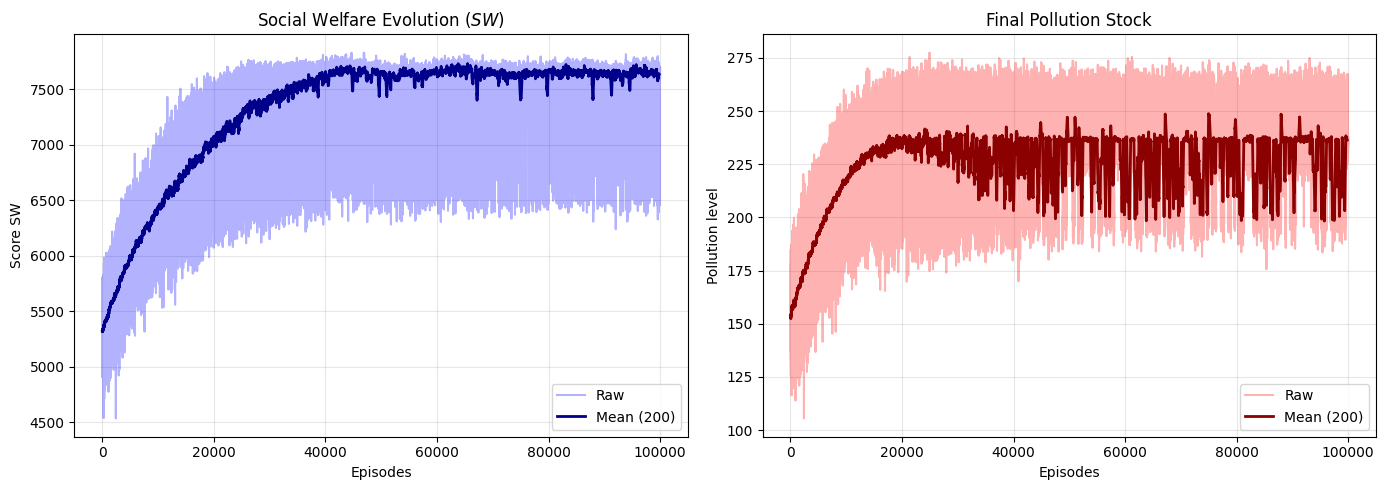

In [14]:
plot_convergence(history_sw, history_pol)

gov policy

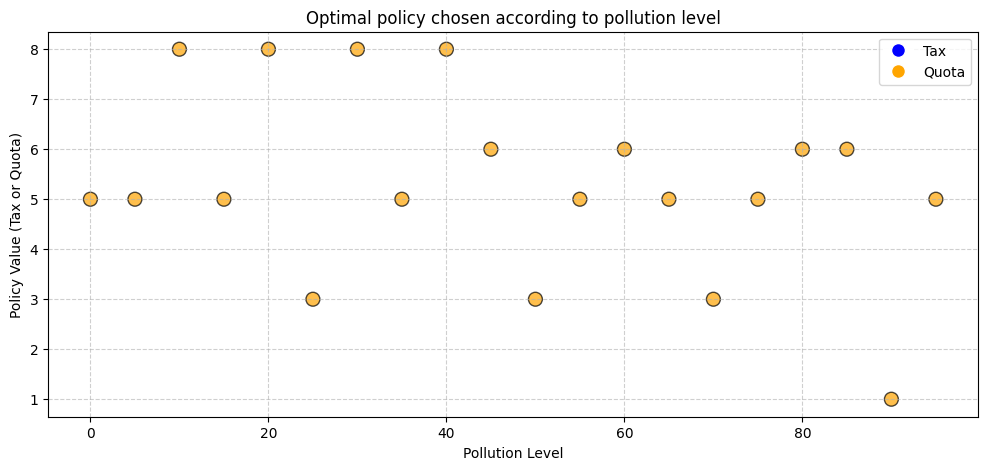

In [15]:
plot_gov_decisions(gov)

firm response

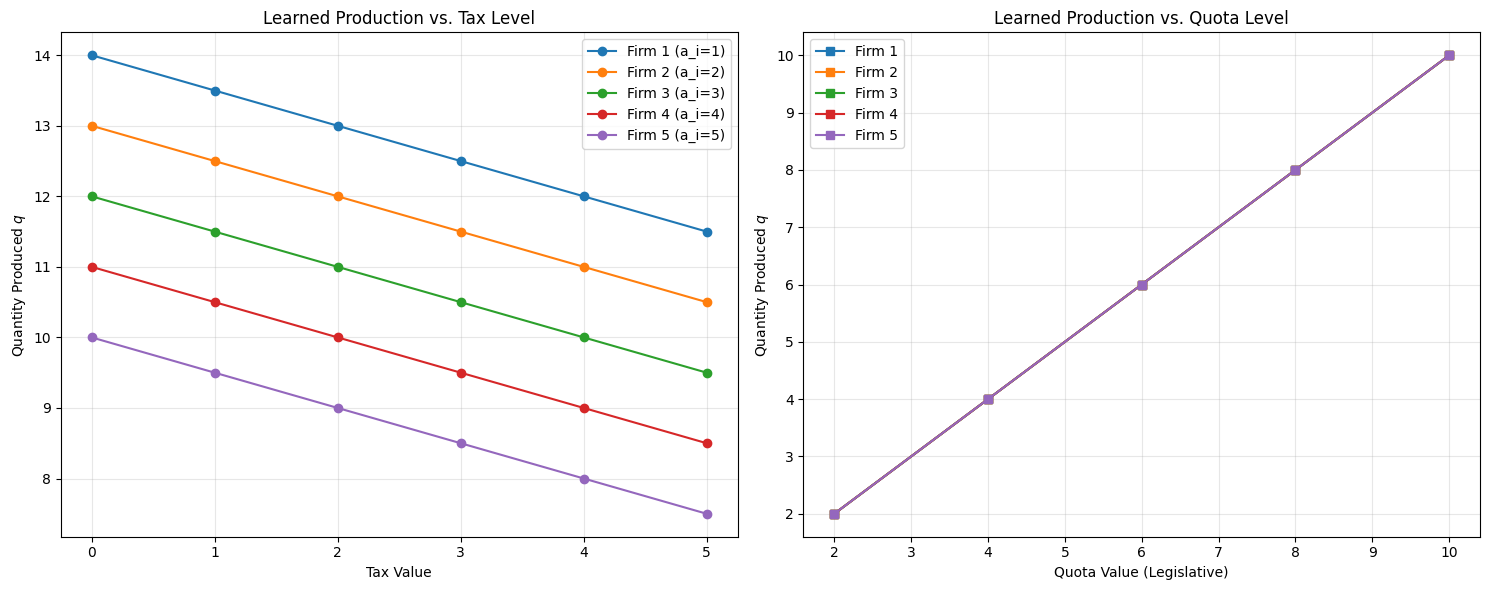

In [16]:
plot_policy_responses(firms)

# penality : expected srasa vs q learning 

In [ ]:
q learning

In [17]:
env = env_penalty_module.EcoSystem()
gov = agents_penalty_module.GovernmentAgent()
firms = [agents_penalty_module.FirmAgent() for _ in range(env.n_firms)]
history_sw_q = []
history_pol_q = []
history_done_q = []

for ep in range(n_episodes):
    state_vec = env.reset()
    pollution = state_vec[2]
    ep_sw = 0
    episode_done = False

    for step in range(n_steps):
        gov_idx = gov.get_action(pollution)
        a_type, a_val = gov.actions[gov_idx]

        q_indices, q_vals = [], []
        for f in firms:
            idx = f.get_action(a_type, a_val)
            q_indices.append(idx)
            q_vals.append(f.actions[idx])

          
        next_state_vec, reward_gov, rewards_firms, done = env.step_multi_firms(a_type, a_val, q_vals)
        next_pollution = next_state_vec[2]

        # We add the reward to the cumulative social welfare BEFORE the break
        ep_sw += reward_gov

        # learning
        gov.learn(pollution, gov_idx, reward_gov, next_pollution, done)
        
        for i in range(len(firms)):
            firms[i].learn(a_type, a_val, q_indices[i], rewards_firms[i])

        
        pollution = next_pollution

        if done:
            episode_done = True
            break

    
    history_sw_q.append(ep_sw)
    history_pol_q.append(pollution)
    history_done_q.append(episode_done)

    gov.decay_epsilon()
    for f in firms:
        f.decay_epsilon()

    if ep % 5000 == 0:
        print(f"Episode {ep} finished. SW: {ep_sw:.1f}, Epsilon: {gov.epsilon:.2f}")

Episode 0 finished. SW: -6359.0, Epsilon: 1.00
Episode 5000 finished. SW: -6210.8, Epsilon: 0.61
Episode 10000 finished. SW: -6721.6, Epsilon: 0.37
Episode 15000 finished. SW: -5897.8, Epsilon: 0.22
Episode 20000 finished. SW: 6809.3, Epsilon: 0.14
Episode 25000 finished. SW: 7057.3, Epsilon: 0.08
Episode 30000 finished. SW: 7138.6, Epsilon: 0.05
Episode 35000 finished. SW: -4990.7, Epsilon: 0.03
Episode 40000 finished. SW: -4300.3, Epsilon: 0.02
Episode 45000 finished. SW: 7211.3, Epsilon: 0.01
Episode 50000 finished. SW: 7307.9, Epsilon: 0.01
Episode 55000 finished. SW: 7290.7, Epsilon: 0.01
Episode 60000 finished. SW: 7273.3, Epsilon: 0.01
Episode 65000 finished. SW: 7290.8, Epsilon: 0.01
Episode 70000 finished. SW: 7282.8, Epsilon: 0.01
Episode 75000 finished. SW: 7308.9, Epsilon: 0.01
Episode 80000 finished. SW: 7240.2, Epsilon: 0.01
Episode 85000 finished. SW: -3447.9, Epsilon: 0.01
Episode 90000 finished. SW: 7287.2, Epsilon: 0.01
Episode 95000 finished. SW: 7285.3, Epsilon: 0.0

Sarsa

In [18]:
env_sarsa = env_penalty_module.EcoSystem()
gov_sarsa = agents_penalty_module.GovernmentAgent()
firms_sarsa = [agents_penalty_module.FirmAgent() for _ in range(env_sarsa.n_firms)]
history_sw_sarsa = []
history_pol_sarsa = []
history_done_sarsa = []

for ep in range(n_episodes):
    state_vec = env_sarsa.reset()
    pollution = state_vec[2]
    ep_sw = 0
    episode_done = False

    for step in range(n_steps):
        gov_idx = gov_sarsa.get_action(pollution)
        a_type, a_val = gov_sarsa.actions[gov_idx]

        q_indices, q_vals = [], []
        for f in firms_sarsa:
            idx = f.get_action(a_type, a_val)
            q_indices.append(idx)
            q_vals.append(f.actions[idx])

        next_state_vec, reward_gov, rewards_firms, done = env_sarsa.step_multi_firms(a_type, a_val, q_vals)
        next_pollution = next_state_vec[2]
        ep_sw += reward_gov
        for i in range(env_sarsa.n_firms):
            firms_sarsa[i].learn(a_type, a_val, q_indices[i], rewards_firms[i])

        gov_sarsa.learn_expected_sarsa(pollution, gov_idx, reward_gov, next_pollution, done)

        pollution = next_pollution

        if done:
            episode_done = True
            break

    history_sw_sarsa.append(ep_sw)
    history_pol_sarsa.append(pollution)
    history_done_sarsa.append(episode_done)

    gov_sarsa.decay_epsilon()
    for f in firms_sarsa:
        f.decay_epsilon()

    if ep % 5000 == 0:
        print(f"Episode {ep} finished. SW: {ep_sw:.1f}, Epsilon: {gov_sarsa.epsilon:.2f}")

Episode 0 finished. SW: -6736.0, Epsilon: 1.00
Episode 5000 finished. SW: -6541.0, Epsilon: 0.61
Episode 10000 finished. SW: 4210.2, Epsilon: 0.37
Episode 15000 finished. SW: -4646.9, Epsilon: 0.22
Episode 20000 finished. SW: 5150.7, Epsilon: 0.14
Episode 25000 finished. SW: 4683.1, Epsilon: 0.08
Episode 30000 finished. SW: 5114.8, Epsilon: 0.05
Episode 35000 finished. SW: 5339.3, Epsilon: 0.03
Episode 40000 finished. SW: 5517.4, Epsilon: 0.02
Episode 45000 finished. SW: 6200.9, Epsilon: 0.01
Episode 50000 finished. SW: 5524.4, Epsilon: 0.01
Episode 55000 finished. SW: 7195.5, Epsilon: 0.01
Episode 60000 finished. SW: 6541.5, Epsilon: 0.01
Episode 65000 finished. SW: 6037.0, Epsilon: 0.01
Episode 70000 finished. SW: 5535.2, Epsilon: 0.01
Episode 75000 finished. SW: -4705.9, Epsilon: 0.01
Episode 80000 finished. SW: 5547.0, Epsilon: 0.01
Episode 85000 finished. SW: 5476.0, Epsilon: 0.01
Episode 90000 finished. SW: 5535.2, Epsilon: 0.01
Episode 95000 finished. SW: 5472.0, Epsilon: 0.01


risk

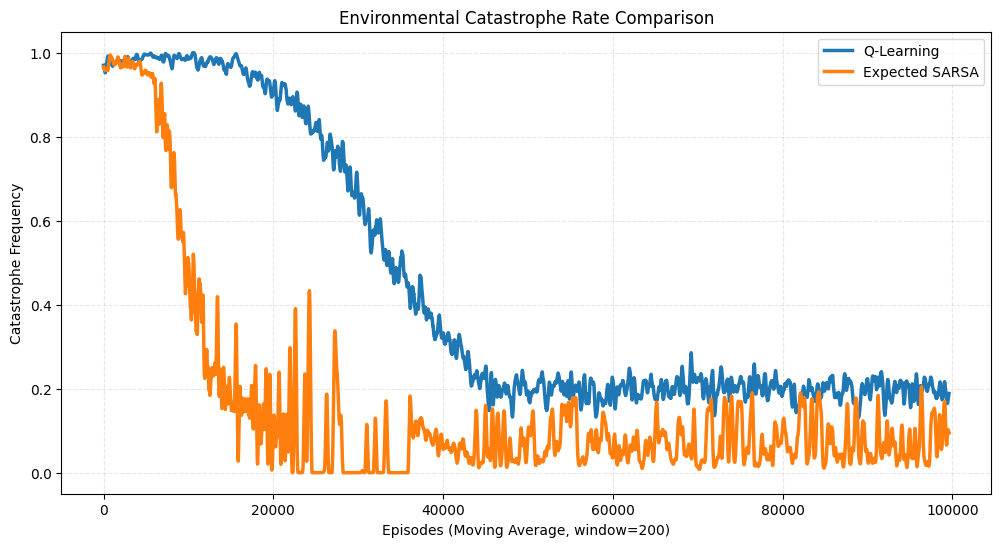

In [33]:
cat_rate_sarsa = np.convolve(history_done_sarsa, np.ones(window)/window, mode='valid')
cat_rate_q = np.convolve(history_done_q, np.ones(window)/window, mode='valid')
plot_catastrophe_comparison(cat_rate_q, cat_rate_sarsa)

SW

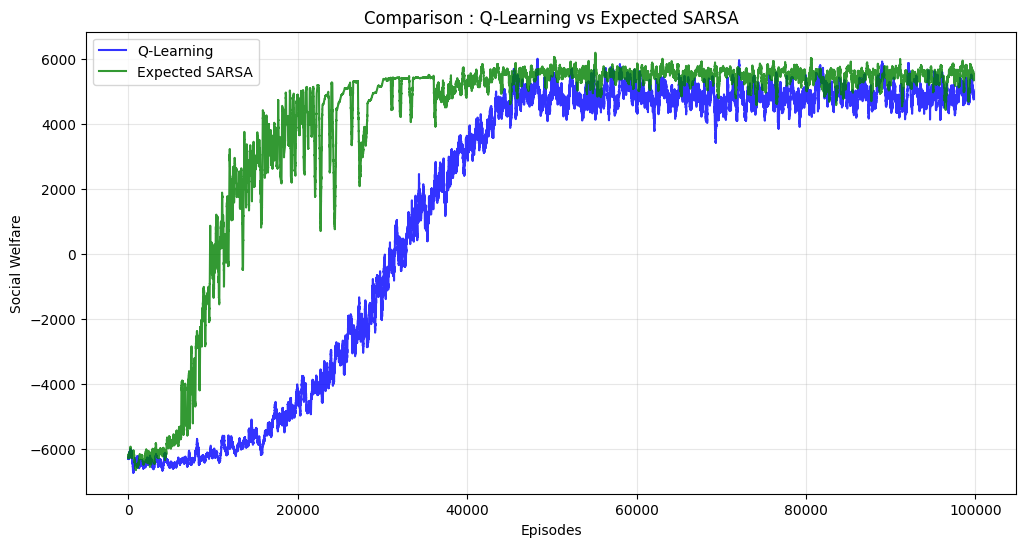

In [29]:
plot_comparison_SW(history_sw_q, history_sw_sarsa)

Parameteres

In [23]:
def run_ablation(param_name, values, n_episodes=n_episodes):
    results = {}

    for val in values:
        print(f"Testing {param_name} = {val}")
        env = env_module.EcoSystem()
        
        if param_name == 'alpha' or param_name == 'lr':
            gov = agent_module.GovernmentAgent(lr=val)
            firms = [agent_module.FirmAgent(lr=val) for _ in range(env.n_firms)]
        else:
            setattr(env, param_name, val)
            gov = agent_module.GovernmentAgent()
            firms = [agent_module.FirmAgent() for _ in range(env.n_firms)]

        for ep in range(n_episodes):
            state = env.reset()
            pollution = state[2]
            for step in range(n_steps):
                g_idx = gov.get_action(pollution)
                a_type, a_val = gov.actions[g_idx]

                f_indices = [f.get_action(a_type, a_val) for f in firms]
                q_vals = [f.actions[idx] for f, idx in zip(firms, f_indices)]

                next_state, r_gov, r_firms = env.step_multi_firms(a_type, a_val, q_vals)
                
                gov.learn(pollution, g_idx, r_gov, env.pollution)
                
                for i in range(len(firms)):
                    firms[i].learn(a_type, a_val, f_indices[i], r_firms[i])

                pollution = env.pollution

            gov.decay_epsilon()
            for f in firms: f.decay_epsilon()

        results[val] = gov
    return results

In [24]:
lambda_vals = [0.1, 1.0, 5.0, 10.0]
results_lambda = run_ablation('lambda_env', lambda_vals)
plot_policy_shift(results_lambda, "Damage Coeff ($\lambda$)")

Testing lambda_env = 0.1


KeyboardInterrupt: 

In [25]:
rho_vals = [0.1, 0.5, 0.8, 0.95]
results_rho = run_ablation('rho', rho_vals)

plot_policy_shift(results_rho, "Persistence ($\\rho$)")

Testing rho = 0.1


KeyboardInterrupt: 

In [26]:
price_vals = [10.0, 15.0, 20.0, 30.0]
results_price = run_ablation('p', price_vals)

plot_policy_shift(results_price, "Market Price ($p$)")

Testing p = 10.0


KeyboardInterrupt: 

In [27]:
alpha_vals = [0.01, 0.1, 0.5, 0.9]
results_alpha = run_ablation('alpha', alpha_vals)

plot_policy_shift(results_alpha, r"Learning Rate ($\alpha$)")

Testing alpha = 0.01


KeyboardInterrupt: 